# Upload Dataset

In [1]:
from keras.datasets import reuters

(train_data, train_labels), (test_data, test_labels) = reuters.load_data(
num_words=10000)

2110848/2110848 [==============================] - 0s 0us/step


In [2]:
len(train_data)

8982

In [3]:
len(test_data)

2246

In [4]:
train_data[10]

[1,
 245,
 273,
 207,
 156,
 53,
 74,
 160,
 26,
 14,
 46,
 296,
 26,
 39,
 74,
 2979,
 3554,
 14,
 46,
 4689,
 4329,
 86,
 61,
 3499,
 4795,
 14,
 61,
 451,
 4329,
 17,
 12]

# Encoding the data

In [6]:
import numpy as np

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.
    return results
    
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

# One-hot encoding

In [17]:
def to_one_hot(labels, dimension=46):
    results = np.zeros((len(labels), dimension))
    for i, label in enumerate(labels):
        results[i, label] = 1.
    return results

one_hot_train_labels = to_one_hot(train_labels)
one_hot_test_labels = to_one_hot(test_labels)

# Building your network

In [7]:
from keras import models
from keras import layers

model = models.Sequential()
model.add(layers.Dense(64, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(46, activation='softmax'))

2025-03-21 20:50:05.230683: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2025-03-21 20:50:05.230968: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-03-21 20:50:05.231833: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2025-03-21 20:50:05.231973: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-03-21 20:50:05.232583: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


# Compiling the model

In [8]:
model.compile(optimizer='rmsprop',
loss='categorical_crossentropy',
metrics=['accuracy'])

# Setting aside a validation set

In [18]:
x_val = x_train[:1000]
partial_x_train = x_train[1000:]

y_val = one_hot_train_labels[:1000]
partial_y_train = one_hot_train_labels[1000:]

# Training the model

In [23]:
history = model.fit(partial_x_train,partial_y_train,epochs=20,batch_size=512,validation_data=(x_val, y_val))

Epoch 1/20


2025-03-21 21:50:24.336804: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


16/16 [==============================] - ETA: 0s - loss: 2.5604 - accuracy: 0.5237

2025-03-21 21:50:28.123461: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


16/16 [==============================] - 4s 80ms/step - loss: 2.5604 - accuracy: 0.5237 - val_loss: 1.7666 - val_accuracy: 0.6450
Epoch 2/20
16/16 [==============================] - 0s 18ms/step - loss: 1.4637 - accuracy: 0.7048 - val_loss: 1.3244 - val_accuracy: 0.7090
Epoch 3/20
16/16 [==============================] - 0s 19ms/step - loss: 1.0828 - accuracy: 0.7726 - val_loss: 1.1684 - val_accuracy: 0.7310
Epoch 4/20
16/16 [==============================] - 0s 21ms/step - loss: 0.8518 - accuracy: 0.8208 - val_loss: 1.0454 - val_accuracy: 0.7770
Epoch 5/20
16/16 [==============================] - 0s 18ms/step - loss: 0.6808 - accuracy: 0.8618 - val_loss: 0.9765 - val_accuracy: 0.8070
Epoch 6/20
16/16 [==============================] - 0s 18ms/step - loss: 0.5454 - accuracy: 0.8923 - val_loss: 0.9235 - val_accuracy: 0.8040
Epoch 7/20
16/16 [==============================] - 0s 18ms/step - loss: 0.4409 - accuracy: 0.9108 - val_loss: 0.8911 - val_accuracy: 0.8200
Epoch 8/20
16/16 [======

# Plotting the training and validation loss

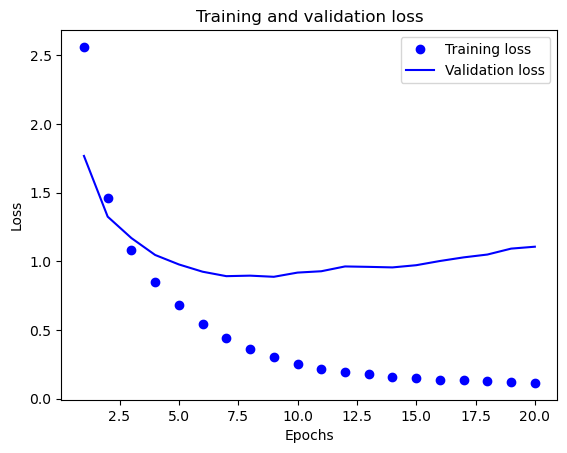

In [24]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Plotting the training and validation accuracy

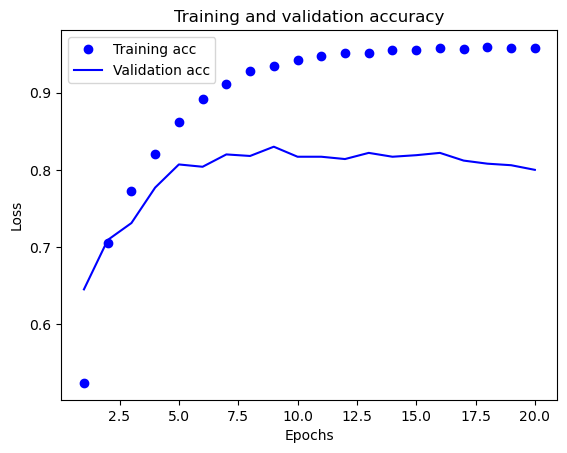

In [26]:
plt.clf()

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Evaulation of model

In [27]:
results = model.evaluate(x_test, one_hot_test_labels)

71/71 [==============================] - 2s 19ms/step - loss: 1.3101 - accuracy: 0.7818


In [28]:
results

[1.310058832168579, 0.7818343639373779]

# Generating predictions for new data

In [29]:
predictions = model.predict(x_test)

40/71 [===============>..............] - ETA: 0s

2025-03-25 10:25:45.778498: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


71/71 [==============================] - 0s 3ms/step


In [31]:
predictions[0].shape

(46,)

In [32]:
np.sum(predictions[0])

1.0

In [33]:
np.argmax(predictions[0]) # The largest entry is the predicted class—the class with the highest probability:

3